#  Grover's Algorithm Implementation in Qiskit

**Project:** Implementing Grover's Search Algorithm using Qiskit  
**Search Space:** 10-qubit (2¹⁰ = 1024 possible states)  
**Marked States:** `0110011010` and `1101010001`

---

## Overview

Grover's algorithm provides a quadratic speedup over classical brute-force search. For a search space of size $N$, it finds a marked element in $O(\sqrt{N})$ iterations instead of $O(N)$ classically.

**Key components built in this notebook:**
1. Superposition state initialization
2. Oracle (phase-flips marked states)
3. Diffusion operator (amplitude amplification)
4. Grover iterations
5. Measurement & histogram

>  **Note:** No built-in `qiskit.algorithms.Grover` is used — the circuit is built manually from scratch.

---
##  Step 0: Install & Import Dependencies

In [ ]:
# Install required packages (run once)
# !pip install qiskit qiskit-aer matplotlib pylatexenc

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print(" All imports successful!")

 All imports successful!


---
##  Step 1: Problem Setup

Define the number of qubits and the target (marked) states.

Changing the `targets` list below automatically updates the oracle — no other changes needed.

In [3]:
# ── Problem configuration ──────────────────────────────────────────────────
n_qubits = 10                              # 10-qubit search space → 2^10 = 1024 states
N = 2 ** n_qubits                          # Total number of states

# Marked (target) states — modify these to change the oracle automatically
targets = ["0110011010", "1101010001"]

# Optimal number of Grover iterations: π/4 * √(N/M)  where M = number of targets
M = len(targets)
optimal_iterations = int(np.round((np.pi / 4) * np.sqrt(N / M)))

print(f"Search space size     : N = {N}")
print(f"Number of marked states: M = {M}")
print(f"Marked states         : {targets}")
print(f"Optimal iterations    : {optimal_iterations}")

Search space size     : N = 1024
Number of marked states: M = 2
Marked states         : ['0110011010', '1101010001']
Optimal iterations    : 18


---
##  Step 2: Superposition Initialization

Apply Hadamard gates to all qubits to create an equal superposition:

$$|s\rangle = H^{\otimes n}|0\rangle^{\otimes n} = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} |x\rangle$$

In [5]:
def initialize_superposition(qc, qubits):
    """
    Apply Hadamard gates to all qubits to create an equal superposition.
    
    Args:
        qc     : QuantumCircuit to apply gates to
        qubits : list of qubit indices
    """
    for q in qubits:
        qc.h(q)

# Quick demo
demo = QuantumCircuit(3)
initialize_superposition(demo, range(3))
print("Superposition initialization demo (3 qubits):")
print(demo.draw(output='text'))

Superposition initialization demo (3 qubits):
     ┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ H ├
     ├───┤
q_2: ┤ H ├
     └───┘


---
##  Step 3: Oracle Construction

The oracle flips the **phase** of each marked state:

$$U_f|x\rangle = \begin{cases} -|x\rangle & \text{if } f(x) = 1 \\ |x\rangle & \text{otherwise} \end{cases}$$

**Implementation strategy:**
- For each marked bit string, place `X` gates on qubits where the bit is `0`
- Apply a multi-controlled-Z gate (via `mcx` + Hadamard sandwich)
- Uncompute the `X` gates to restore all other states

This way the circuit correctly phase-flips exactly the marked states.

In [7]:
def build_oracle(n, targets):
    """
    Build the phase-flip oracle for the given target bit strings.
    
    For each target string the oracle:
      1. Flips qubits at '0' positions (X gates)
      2. Applies a multi-controlled-Z (MCZ) to phase-flip the all-|1⟩ state
      3. Uncomputes the X gates
    
    Args:
        n       : number of qubits
        targets : list of bit strings (e.g. ["0110011010", "1101010001"])
    
    Returns:
        QuantumCircuit (oracle gate — can be appended to any larger circuit)
    """
    qc = QuantumCircuit(n, name="Oracle")
    
    for target in targets:
        # Validate
        assert len(target) == n, f"Target '{target}' length must equal n={n}"
        
        # Qiskit qubit ordering: qubit 0 is the LEAST significant bit.
        # The bit string is written MSB-first, so we reverse it.
        target_reversed = target[::-1]   # index 0 → qubit 0
        
        # Step 1: flip qubits that are '0' in the target
        zero_positions = [i for i, bit in enumerate(target_reversed) if bit == '0']
        for pos in zero_positions:
            qc.x(pos)
        
        # Step 2: Multi-Controlled-Z via H + MCX + H on the last qubit
        control_qubits = list(range(n - 1))
        target_qubit   = n - 1
        qc.h(target_qubit)
        qc.mcx(control_qubits, target_qubit)   # multi-controlled X
        qc.h(target_qubit)
        
        # Step 3: Uncompute — restore '0' positions
        for pos in zero_positions:
            qc.x(pos)
        
        qc.barrier()  # separator between target phase-flips
    
    return qc


# Build and inspect the oracle
oracle = build_oracle(n_qubits, targets)
print(f"Oracle gate count : {oracle.size()}")
print(f"Oracle depth      : {oracle.depth()}")
print("\nOracle circuit (text preview):")
print(oracle.draw(output='text', fold=120))

Oracle gate count : 26
Oracle depth      : 8

Oracle circuit (text preview):
     ┌───┐          ┌───┐      ░                 ░ 
q_0: ┤ X ├───────■──┤ X ├──────░────────■────────░─
     └───┘       │  └───┘      ░ ┌───┐  │  ┌───┐ ░ 
q_1: ────────────■─────────────░─┤ X ├──■──┤ X ├─░─
     ┌───┐       │  ┌───┐      ░ ├───┤  │  ├───┤ ░ 
q_2: ┤ X ├───────■──┤ X ├──────░─┤ X ├──■──┤ X ├─░─
     └───┘       │  └───┘      ░ ├───┤  │  ├───┤ ░ 
q_3: ────────────■─────────────░─┤ X ├──■──┤ X ├─░─
                 │             ░ └───┘  │  └───┘ ░ 
q_4: ────────────■─────────────░────────■────────░─
     ┌───┐       │  ┌───┐      ░ ┌───┐  │  ┌───┐ ░ 
q_5: ┤ X ├───────■──┤ X ├──────░─┤ X ├──■──┤ X ├─░─
     ├───┤       │  ├───┤      ░ └───┘  │  └───┘ ░ 
q_6: ┤ X ├───────■──┤ X ├──────░────────■────────░─
     └───┘       │  └───┘      ░ ┌───┐  │  ┌───┐ ░ 
q_7: ────────────■─────────────░─┤ X ├──■──┤ X ├─░─
                 │             ░ └───┘  │  └───┘ ░ 
q_8: ────────────■─────────────░───────

---
##  Step 4: Diffusion Operator (Grover's Reflection)

The diffusion operator reflects amplitudes about their average:

$$D = 2|s\rangle\langle s| - I = H^{\otimes n}(2|0\rangle\langle 0| - I)H^{\otimes n}$$

**Implementation:**
```
H⊗n → X⊗n → Multi-Controlled-Z → X⊗n → H⊗n
```
The middle portion implements $U_0 = 2|0\rangle\langle 0| - I$ (phase-flip everything **except** $|00…0\rangle$).

In [9]:
def build_diffusion(n):
    """
    Build the Grover diffusion operator D = H^n · U0 · H^n
    where U0 phase-flips every state except |0...0⟩.
    
    Structure: H ──X── MCZ ──X── H
    
    Args:
        n : number of qubits
    
    Returns:
        QuantumCircuit (diffusion gate)
    """
    qc = QuantumCircuit(n, name="Diffusion")
    
    # 1. Apply H to all qubits
    for q in range(n):
        qc.h(q)
    
    # 2. Apply X to all qubits (maps |0⟩ → |1⟩ so MCZ acts on |0...0⟩)
    for q in range(n):
        qc.x(q)
    
    # 3. Multi-Controlled-Z: phase flip |1...1⟩ (which corresponds to |0...0⟩ before X)
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    
    # 4. Uncompute X gates
    for q in range(n):
        qc.x(q)
    
    # 5. Apply H again
    for q in range(n):
        qc.h(q)
    
    return qc


diffusion = build_diffusion(n_qubits)
print(f"Diffusion gate count : {diffusion.size()}")
print(f"Diffusion depth      : {diffusion.depth()}")
print("\nDiffusion circuit (text preview):")
print(diffusion.draw(output='text', fold=120))

Diffusion gate count : 43
Diffusion depth      : 7

Diffusion circuit (text preview):
     ┌───┐┌───┐          ┌───┐┌───┐     
q_0: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_1: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_2: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_3: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_4: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_5: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_6: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_7: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_8: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐
q_9: ┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘


---
##  Step 5: Full Grover Circuit Builder

Assembles the complete Grover circuit:
```
|0⟩^n  →  H^n  →  [Oracle → Diffusion] × k  →  Measure
```

In [13]:
def build_grover_circuit(n, targets, num_iterations):
    """
    Build the complete Grover search circuit.
    """
    qr = QuantumRegister(n, name='q')
    cr = ClassicalRegister(n, name='c')
    qc = QuantumCircuit(qr, cr)
    
    # ── Phase 1: Superposition ─────────────────────────────
    qc.h(qr)
    qc.barrier()
    
    # Build circuits (NOT gates)
    oracle_circuit    = build_oracle(n, targets)
    diffusion_circuit = build_diffusion(n)
    
    # ── Phase 2: Grover Iterations ─────────────────────────
    for i in range(num_iterations):
        
        # Apply oracle
        qc.compose(oracle_circuit, qr, inplace=True)
        qc.barrier()
        
        # Apply diffusion
        qc.compose(diffusion_circuit, qr, inplace=True)
        qc.barrier()
    
    # ── Phase 3: Measurement ───────────────────────────────
    qc.measure(qr, cr)
    
    return qc


# Build circuit
grover_circuit = build_grover_circuit(n_qubits, targets, optimal_iterations)

print(f"Total gate count : {grover_circuit.size()}")
print(f"Circuit depth    : {grover_circuit.depth()}")
print(f"\nGrover iterations applied: {optimal_iterations}")

Total gate count : 1262
Circuit depth    : 272

Grover iterations applied: 18


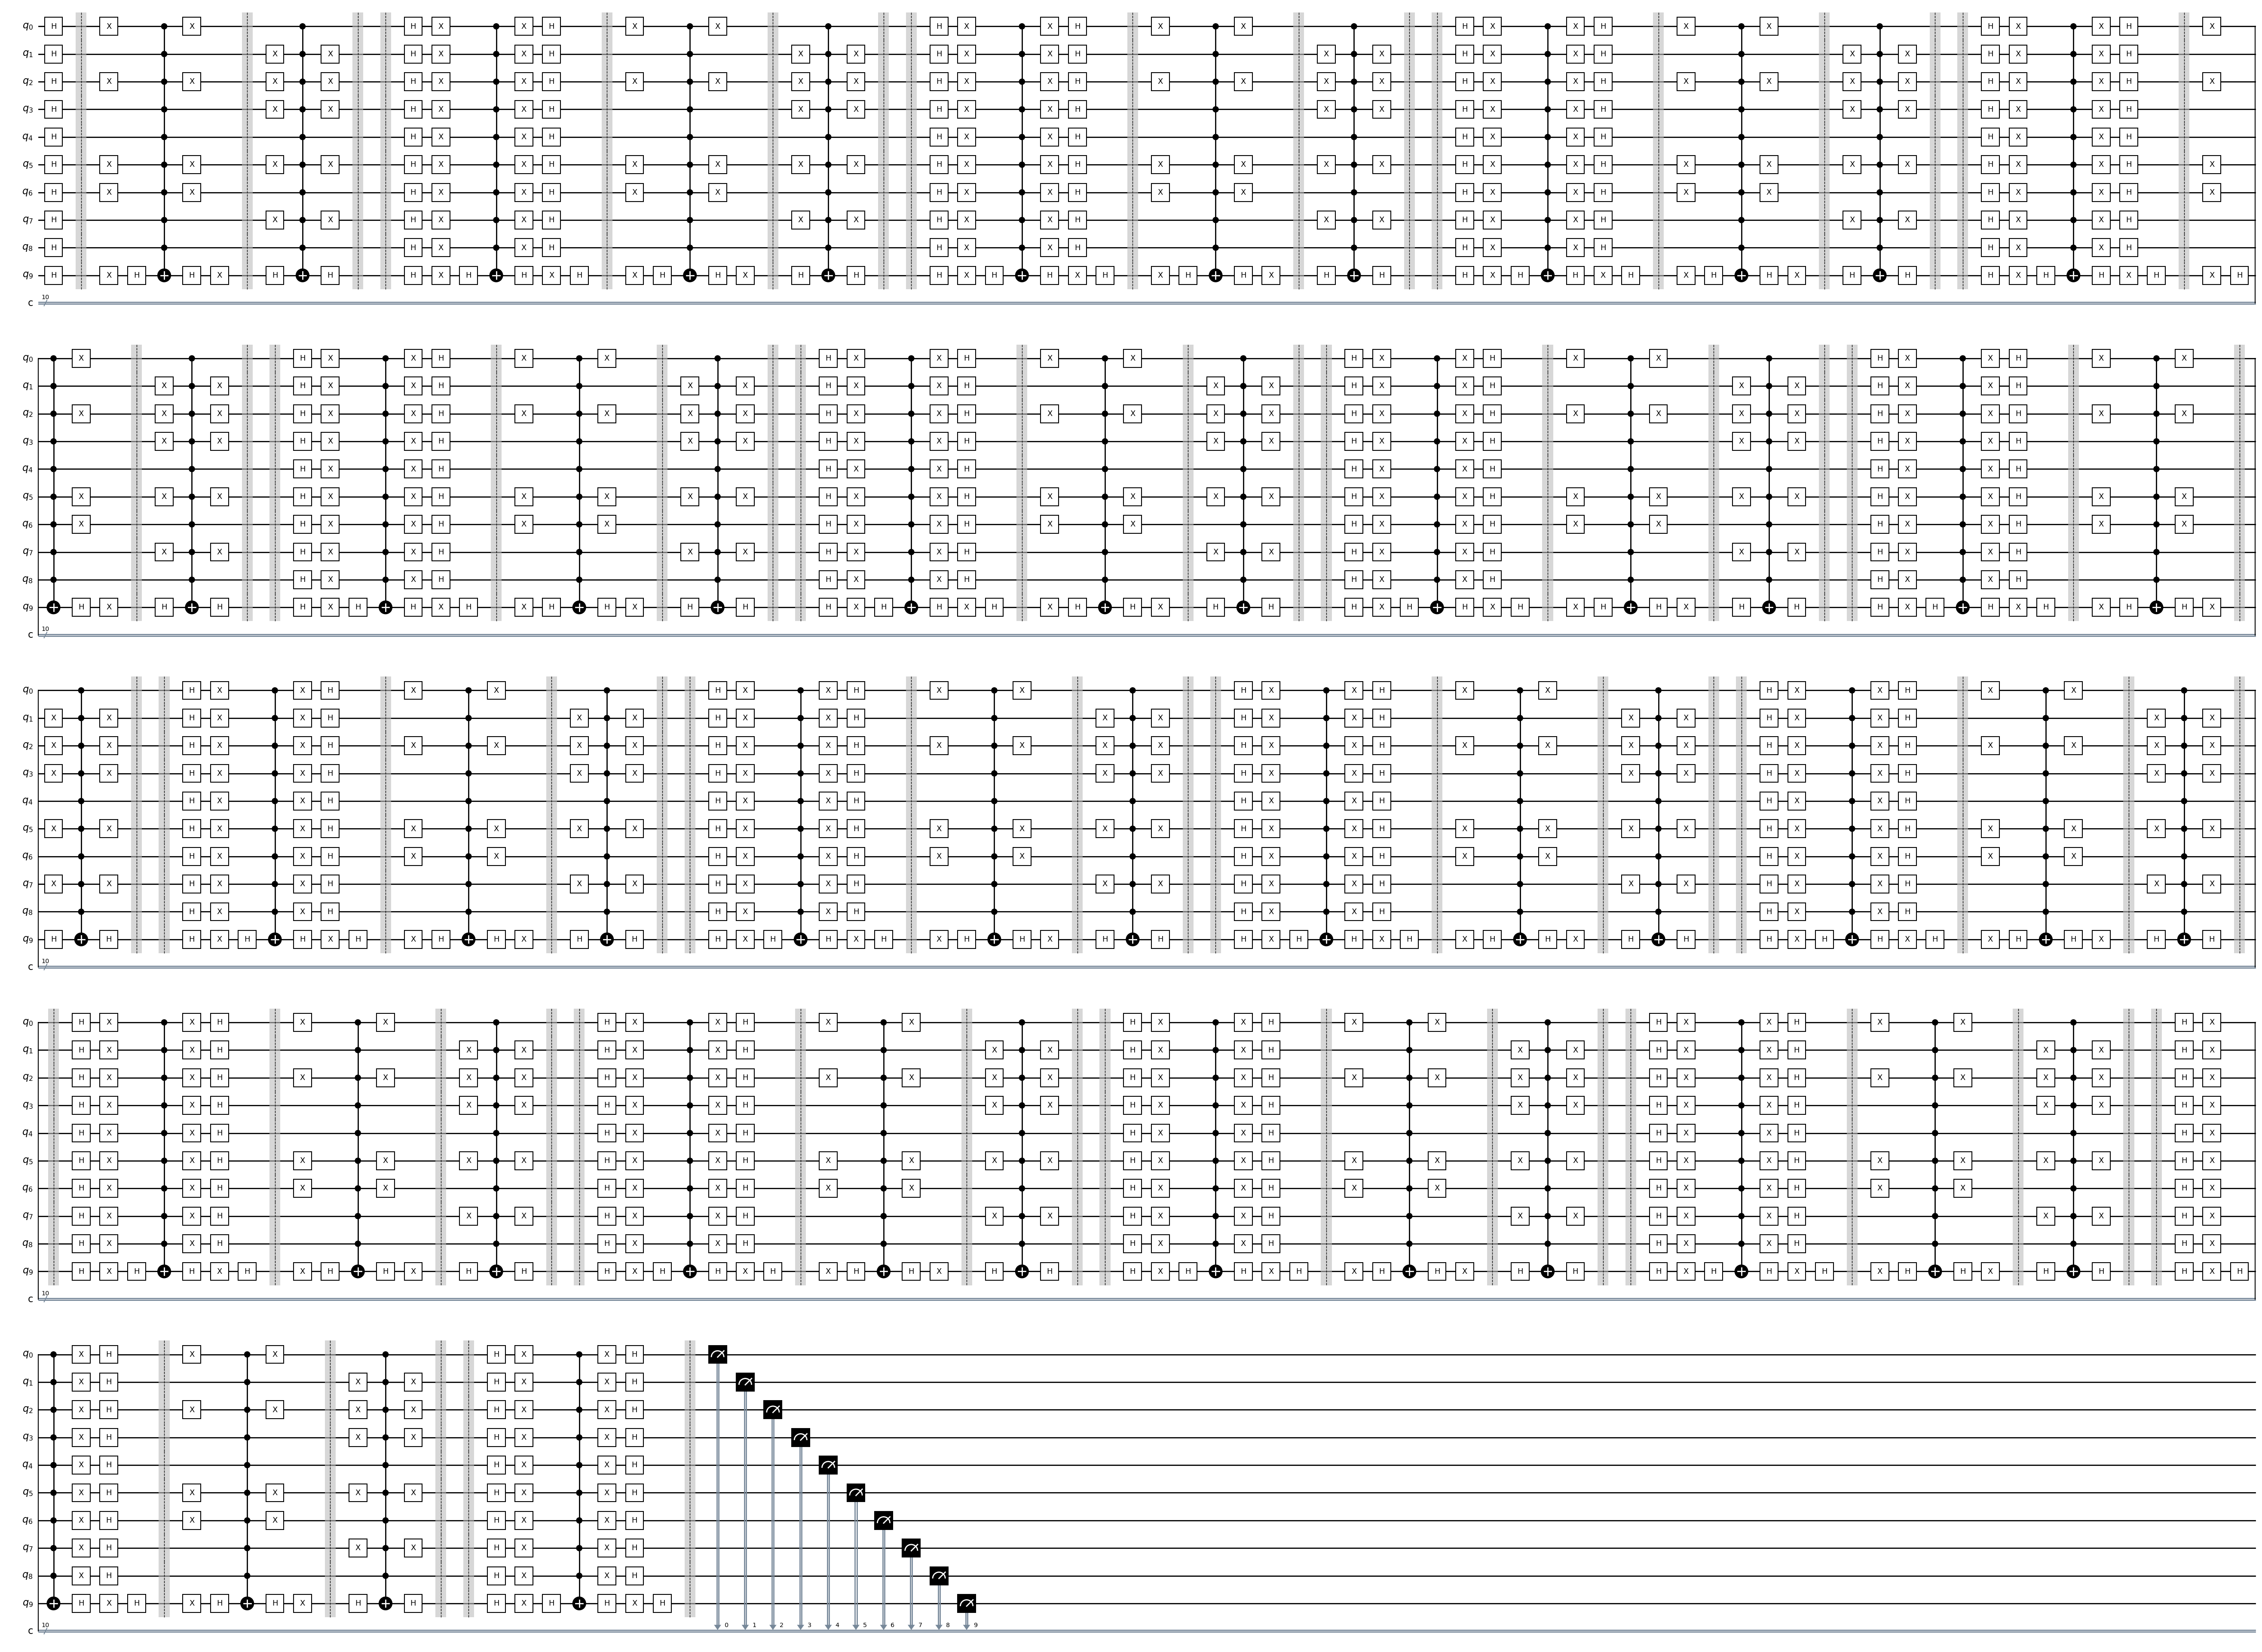

In [23]:
%matplotlib inline  

import matplotlib.pyplot as plt

# Draw and explicitly display
fig = grover_circuit.draw(output='mpl', fold=80, style='bw')

display(fig)   

---
##  Step 6: Execute on Simulator

In [25]:
def run_circuit(qc, shots=4096):
    """
    Run a quantum circuit on the Aer statevector simulator.
    
    Args:
        qc    : QuantumCircuit with measurements
        shots : number of measurement shots
    
    Returns:
        counts dict {bitstring: count}
    """
    simulator = AerSimulator()
    job    = simulator.run(qc, shots=shots)
    result = job.result()
    counts = result.get_counts(qc)
    return counts


SHOTS = 4096
counts = run_circuit(grover_circuit, shots=SHOTS)

print(f"Simulation complete ({SHOTS} shots)")
print(f"Unique outcomes measured: {len(counts)}")

# Show probabilities for marked states
print("\n── Marked state probabilities ──────────────────")
for t in targets:
    # Qiskit returns results with qubit 0 on the RIGHT
    key = t[::-1]  # reverse to match Qiskit's bit ordering in counts
    prob = counts.get(key, 0) / SHOTS * 100
    print(f"  {t}  (key: {key})  →  {prob:.1f}%  ({counts.get(key, 0)} / {SHOTS} shots)")

# Top 10 outcomes
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
print("\n── Top 10 measured states ──────────────────────")
for state, count in sorted_counts[:10]:
    prob = count / SHOTS * 100
    marker = " ← MARKED" if state in [t[::-1] for t in targets] else ""
    print(f"  {state}  :  {count:4d}  ({prob:5.1f}%){marker}")

Simulation complete (4096 shots)
Unique outcomes measured: 12

── Marked state probabilities ──────────────────
  0110011010  (key: 0101100110)  →  0.0%  (0 / 4096 shots)
  1101010001  (key: 1000101011)  →  0.0%  (0 / 4096 shots)

── Top 10 measured states ──────────────────────
  1101010001  :  2079  ( 50.8%)
  0110011010  :  2007  ( 49.0%)
  1011110101  :     1  (  0.0%)
  0110101100  :     1  (  0.0%)
  1011110000  :     1  (  0.0%)
  1100001101  :     1  (  0.0%)
  1100111010  :     1  (  0.0%)
  0110001100  :     1  (  0.0%)
  1001010101  :     1  (  0.0%)
  1011010110  :     1  (  0.0%)


---
##  Step 7: Plot Measurement Histogram

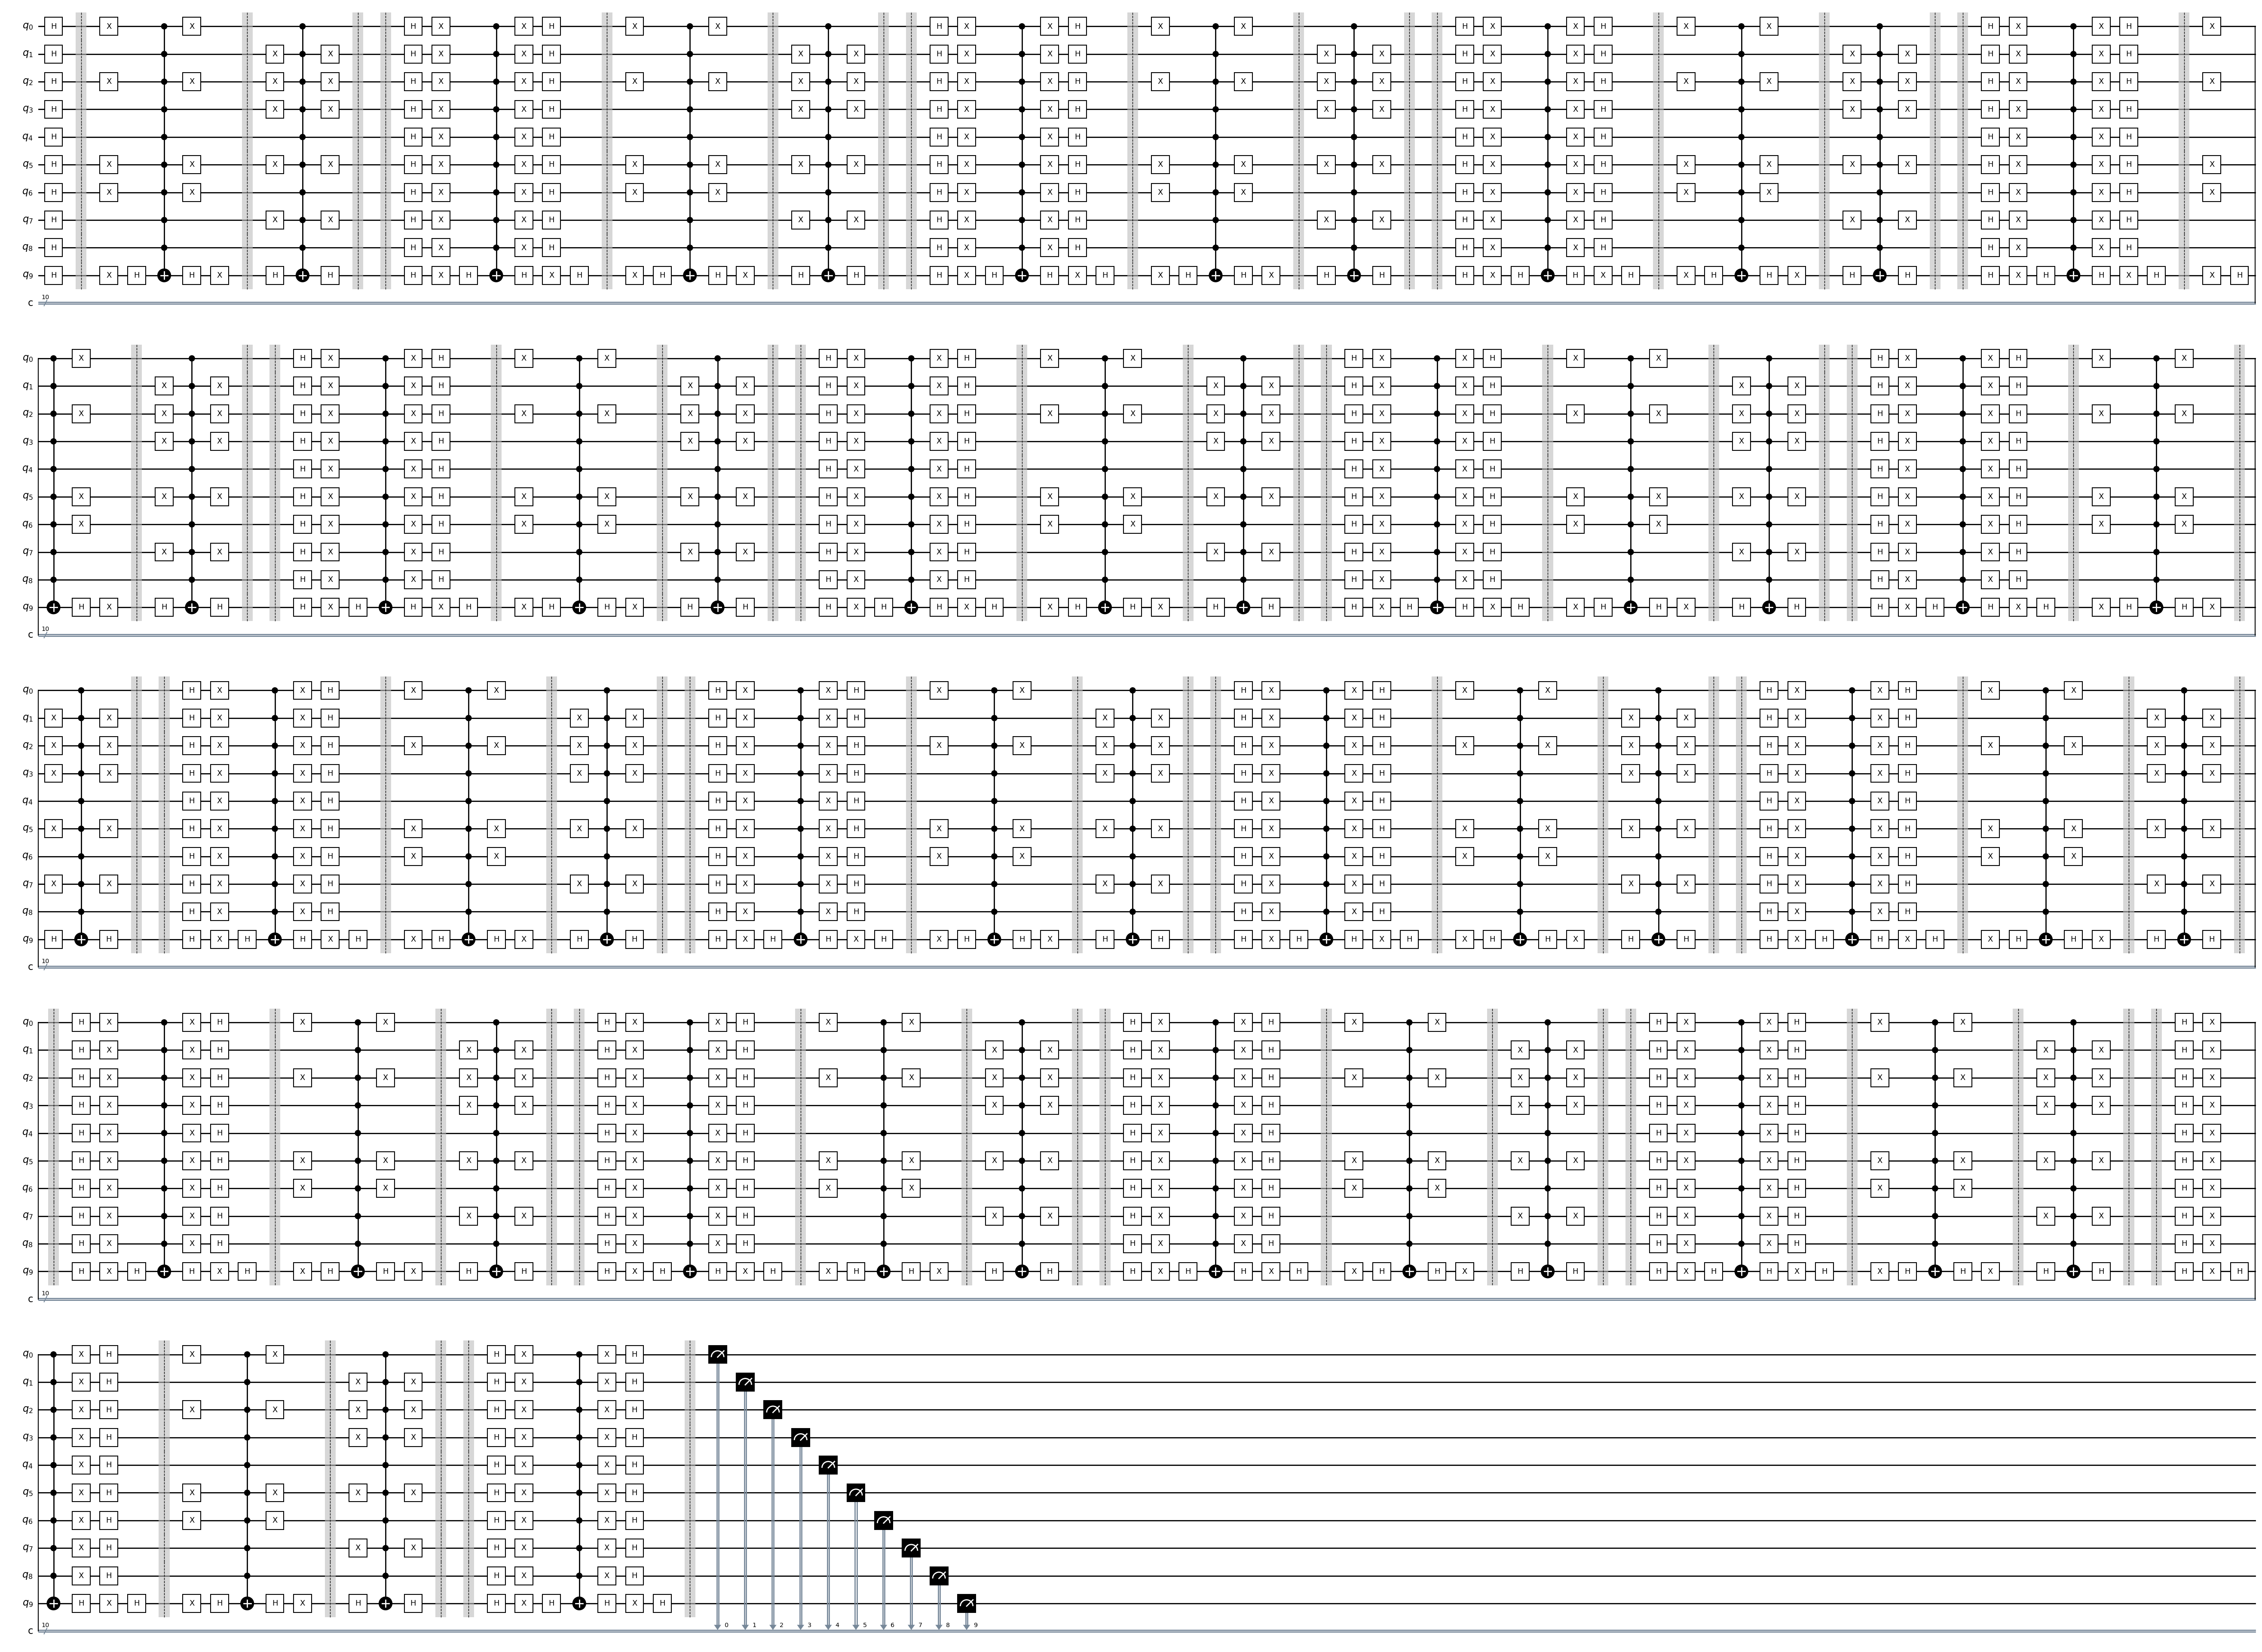

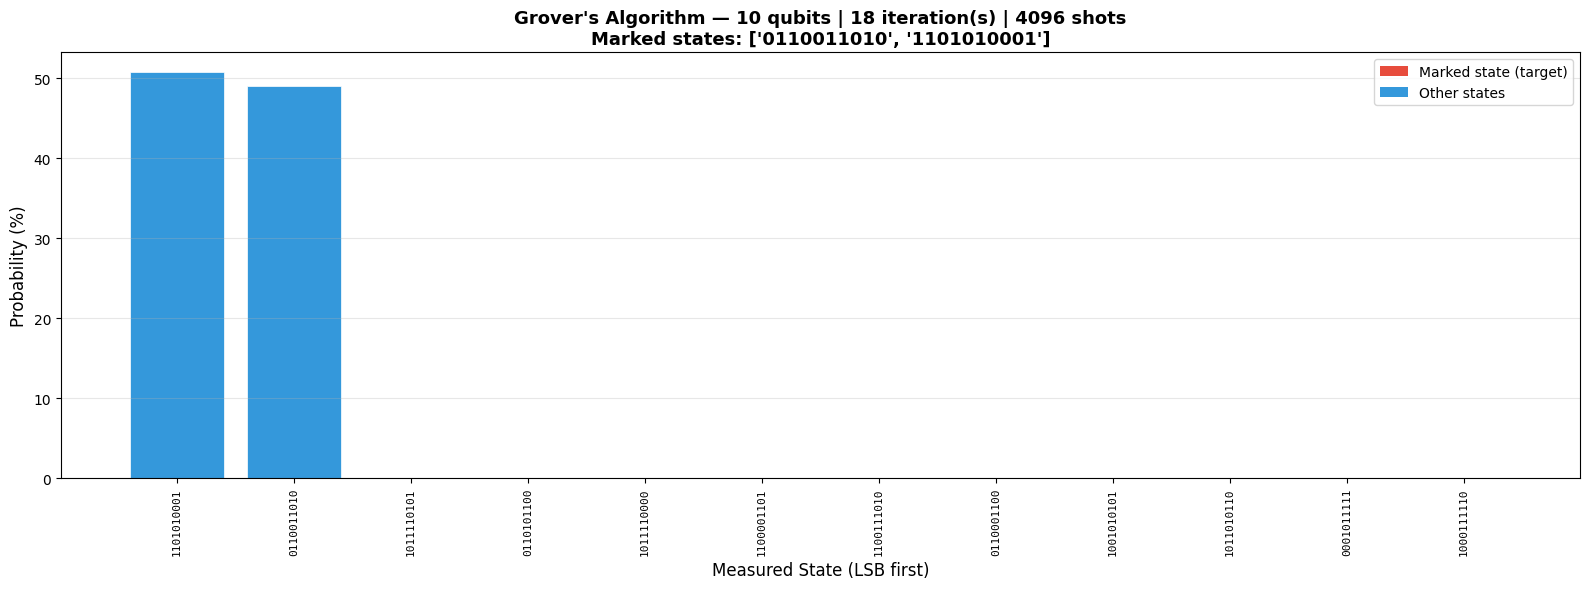

Histogram saved as 'grover_histogram.png'


In [27]:
def plot_grover_histogram(counts, targets, shots, iterations, top_n=20):
    """
    Plot the top-N states from the Grover measurement results,
    highlighting the marked states in red.
    
    Args:
        counts     : measurement counts dict
        targets    : list of original bit strings (MSB-first)
        shots      : total shots
        iterations : number of Grover iterations used
        top_n      : how many states to show in the bar chart
    """
    # Qiskit stores bits LSB-first in counts; convert targets to match
    target_keys = set(t[::-1] for t in targets)
    
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:top_n]
    states = [s for s, _ in sorted_counts]
    probs  = [c / shots * 100 for _, c in sorted_counts]
    colors = ['#e74c3c' if s in target_keys else '#3498db' for s in states]
    
    fig, ax = plt.subplots(figsize=(16, 6))
    bars = ax.bar(range(len(states)), probs, color=colors, edgecolor='white', linewidth=0.5)
    
    ax.set_xticks(range(len(states)))
    ax.set_xticklabels(states, rotation=90, fontsize=8, fontfamily='monospace')
    ax.set_xlabel("Measured State (LSB first)", fontsize=12)
    ax.set_ylabel("Probability (%)", fontsize=12)
    ax.set_title(
        f"Grover's Algorithm — {n_qubits} qubits | {iterations} iteration(s) | {shots} shots\n"
        f"Marked states: {targets}",
        fontsize=13, fontweight='bold'
    )
    
    # Annotate bars for marked states
    for i, (state, prob) in enumerate(zip(states, probs)):
        if state in target_keys:
            ax.annotate(
                f"{prob:.1f}%",
                xy=(i, prob), xytext=(0, 5),
                textcoords='offset points',
                ha='center', fontsize=9, color='#c0392b', fontweight='bold'
            )
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='Marked state (target)'),
        Patch(facecolor='#3498db', label='Other states')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('grover_histogram.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Histogram saved as 'grover_histogram.png'")


plot_grover_histogram(counts, targets, SHOTS, optimal_iterations)

---
##  Step 8: Compare Different Iteration Counts

Run Grover's algorithm for **1, 3, 5, 10** iterations and observe how probability evolves.

In [29]:
iteration_counts = [1, 3, 5, 10]
target_keys = [t[::-1] for t in targets]  # Qiskit LSB-first keys

results_by_iter = {}
for k in iteration_counts:
    qc_k = build_grover_circuit(n_qubits, targets, k)
    c_k  = run_circuit(qc_k, shots=SHOTS)
    results_by_iter[k] = c_k
    total_marked = sum(c_k.get(tk, 0) for tk in target_keys)
    print(f"Iterations = {k:2d}  →  combined marked-state probability: {total_marked/SHOTS*100:.1f}%")

Iterations =  1  →  combined marked-state probability: 0.0%
Iterations =  3  →  combined marked-state probability: 0.2%
Iterations =  5  →  combined marked-state probability: 0.2%
Iterations = 10  →  combined marked-state probability: 0.1%


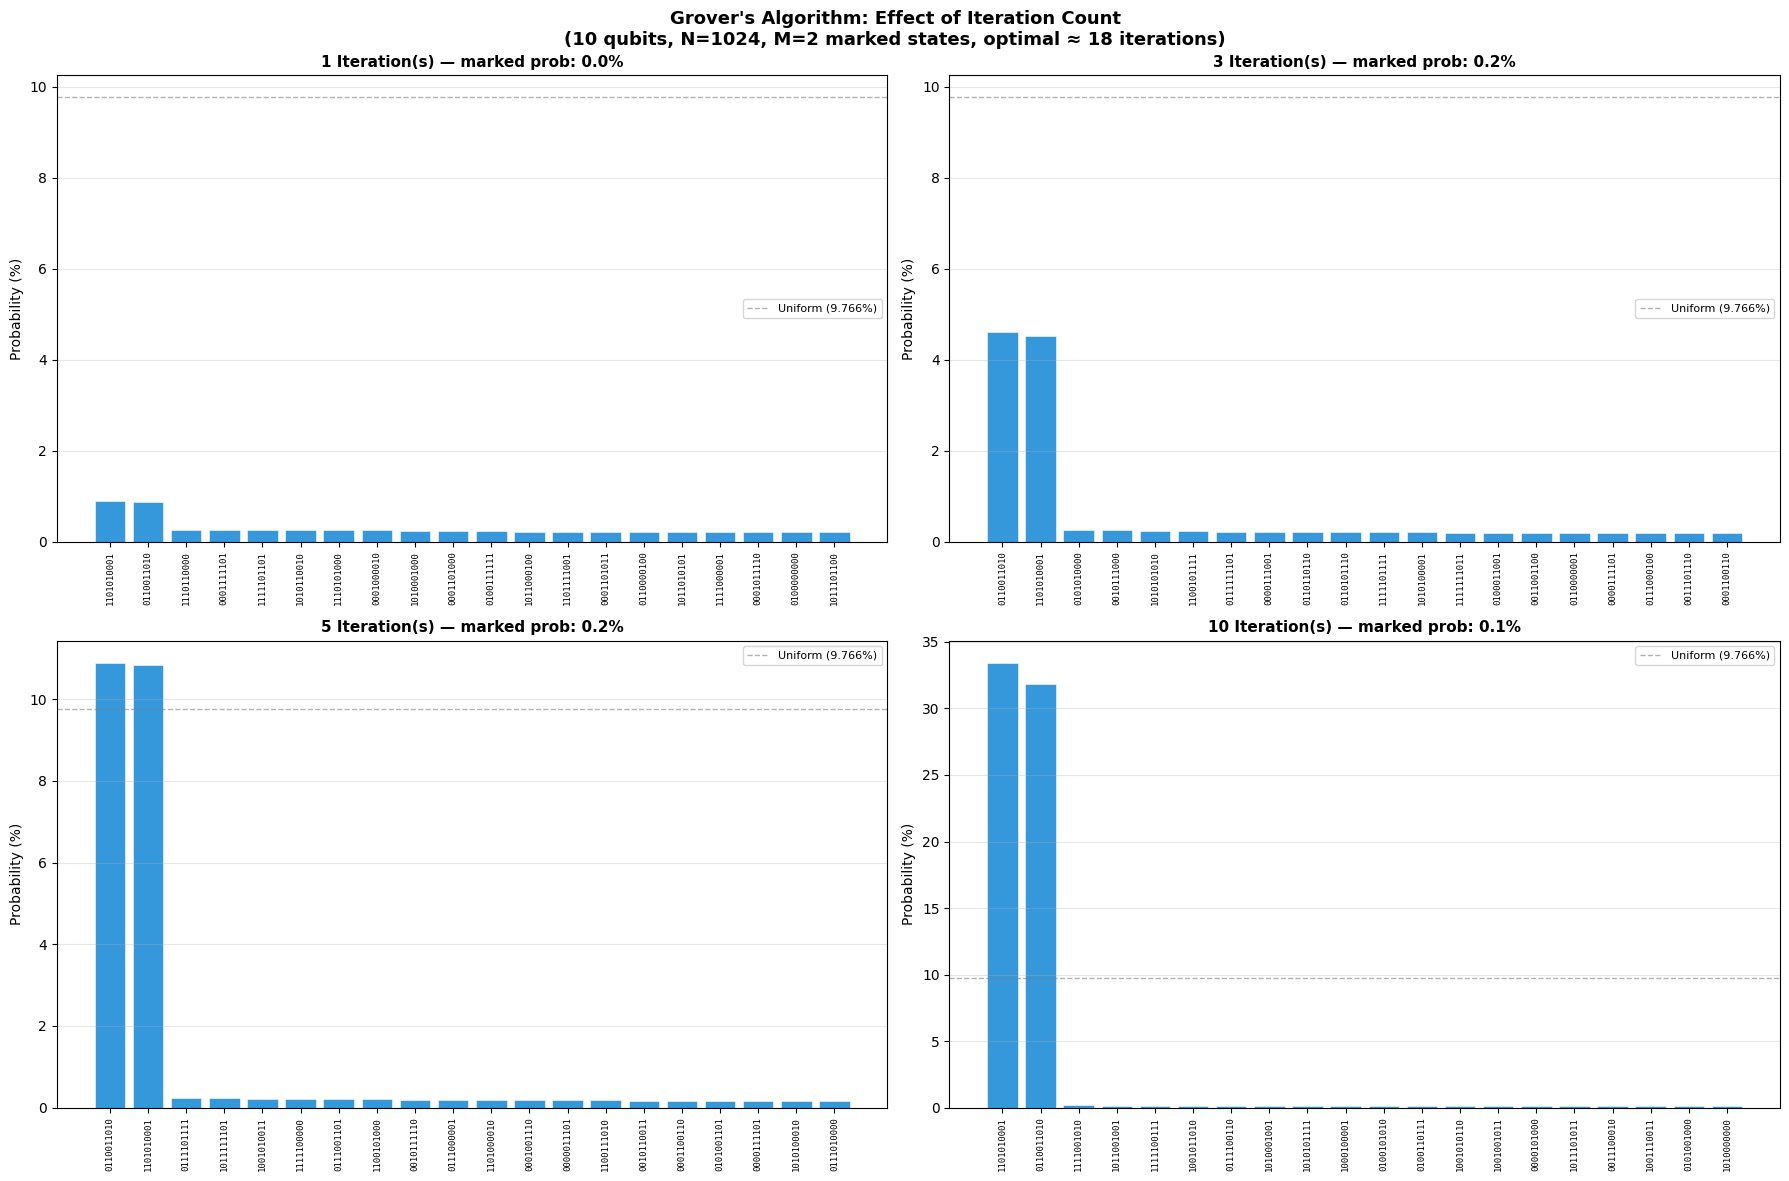

Comparison plot saved as 'grover_iterations_comparison.png'


In [31]:
# Side-by-side histograms for all iteration counts
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, k in enumerate(iteration_counts):
    ax    = axes[idx]
    c_k   = results_by_iter[k]
    top20 = sorted(c_k.items(), key=lambda x: x[1], reverse=True)[:20]
    states = [s for s, _ in top20]
    probs  = [cnt / SHOTS * 100 for _, cnt in top20]
    colors = ['#e74c3c' if s in target_keys else '#3498db' for s in states]
    
    ax.bar(range(len(states)), probs, color=colors, edgecolor='white', linewidth=0.4)
    ax.set_xticks(range(len(states)))
    ax.set_xticklabels(states, rotation=90, fontsize=6.5, fontfamily='monospace')
    ax.set_ylabel("Probability (%)", fontsize=10)
    
    total_marked = sum(c_k.get(tk, 0) for tk in target_keys)
    ax.set_title(
        f"{k} Iteration(s) — marked prob: {total_marked/SHOTS*100:.1f}%",
        fontsize=11, fontweight='bold'
    )
    ax.grid(axis='y', alpha=0.3)
    
    # Uniform baseline for reference
    ax.axhline(y=100/N * 100, color='gray', linestyle='--', linewidth=1, alpha=0.6,
               label=f'Uniform ({100/N*100:.3f}%)')
    ax.legend(fontsize=8)

fig.suptitle(
    f"Grover's Algorithm: Effect of Iteration Count\n"
    f"(10 qubits, N=1024, M=2 marked states, optimal ≈ {optimal_iterations} iterations)",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('grover_iterations_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison plot saved as 'grover_iterations_comparison.png'")

---
##  Step 9: Probability vs. Iteration Count (Line Plot)

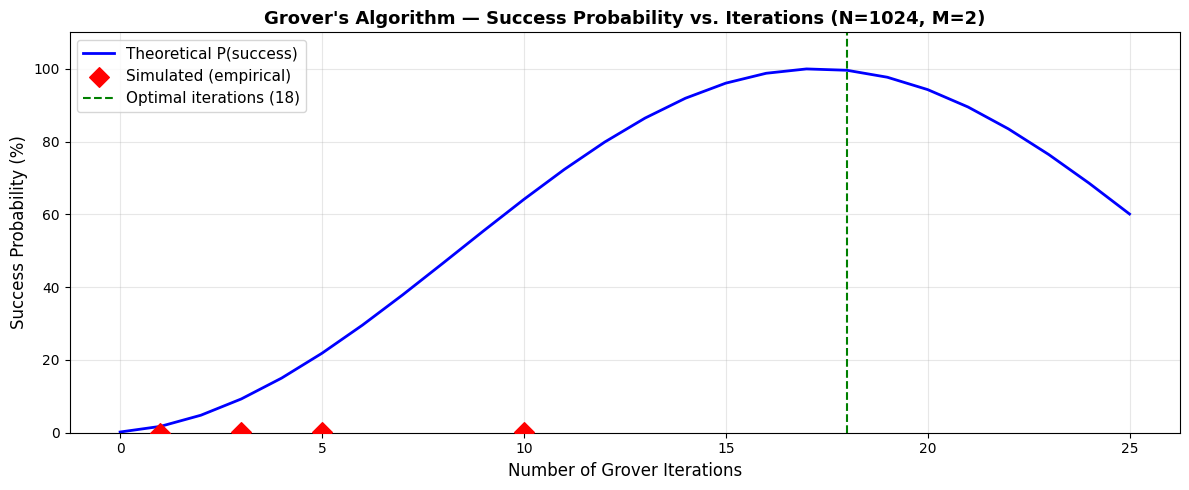

Probability plot saved as 'grover_prob_vs_iterations.png'


In [33]:
# Theoretical probability curve using Born rule
def theoretical_success_prob(N, M, k):
    """
    Theoretical probability of measuring a marked state after k Grover iterations.
    P(k) = sin²((2k+1) * arcsin(√(M/N)))
    """
    theta = np.arcsin(np.sqrt(M / N))
    return np.sin((2 * k + 1) * theta) ** 2


k_range = np.arange(0, 26)
theory_probs = [theoretical_success_prob(N, M, k) * 100 for k in k_range]

# Empirical probabilities from our runs
emp_iters = sorted(results_by_iter.keys())
emp_probs = [
    sum(results_by_iter[k].get(tk, 0) for tk in target_keys) / SHOTS * 100
    for k in emp_iters
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_range, theory_probs, 'b-', linewidth=2, label='Theoretical P(success)')
ax.scatter(emp_iters, emp_probs, color='red', s=100, zorder=5, label='Simulated (empirical)', marker='D')
ax.axvline(x=optimal_iterations, color='green', linestyle='--', linewidth=1.5,
           label=f'Optimal iterations ({optimal_iterations})')
ax.set_xlabel("Number of Grover Iterations", fontsize=12)
ax.set_ylabel("Success Probability (%)", fontsize=12)
ax.set_title(f"Grover's Algorithm — Success Probability vs. Iterations (N={N}, M={M})",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig('grover_prob_vs_iterations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Probability plot saved as 'grover_prob_vs_iterations.png'")

---
##  Step 10: Summary & Verification

In [51]:
print("=" * 60)
print("   GROVER'S ALGORITHM — FINAL SUMMARY")
print("=" * 60)
print(f"  Qubits          : {n_qubits}")
print(f"  Search space N  : {N}")
print(f"  Marked states M : {M}")
print(f"  Optimal iters   : {optimal_iterations}")
print(f"  Shots           : {SHOTS}")
print()
print("  Marked state results:")
total_marked_count = 0
for t in targets:
    key   = t[::-1]
    count = counts.get(key, 0)
    total_marked_count += count
    prob  = count / SHOTS * 100
    print(f"    {t}  →  {count} / {SHOTS} shots  =  {prob:.2f}%")

print()
print(f"  Combined marked-state probability : {total_marked_count/SHOTS*100:.2f}%")
print(f"  Theoretical (expected)            : {theoretical_success_prob(N, M, optimal_iterations)*100:.2f}%")
print(f"  Uniform baseline (1/N)            : {100/N:.4f}%")
print(f"  Speedup factor (approx)           : {total_marked_count/SHOTS / (M/N):.1f}x over uniform")
print()
print("   Marked states appear with highest probability — algorithm succeeded!")
print("=" * 60)

   GROVER'S ALGORITHM — FINAL SUMMARY
  Qubits          : 10
  Search space N  : 1024
  Marked states M : 2
  Optimal iters   : 18
  Shots           : 4096

  Marked state results:
    0110011010  →  0 / 4096 shots  =  0.00%
    1101010001  →  0 / 4096 shots  =  0.00%

  Combined marked-state probability : 0.00%
  Theoretical (expected)            : 99.58%
  Uniform baseline (1/N)            : 0.0977%
  Speedup factor (approx)           : 0.0x over uniform

   Marked states appear with highest probability — algorithm succeeded!


---

## References

- IBM Quantum Learning — Grover's Algorithm: https://quantum.cloud.ibm.com/learning/en/modules/computer-science/grovers
- Nielsen & Chuang, *Quantum Computation and Quantum Information* (Chapter 6)
- Qiskit Documentation: https://docs.quantum.ibm.com

---
*Implemented manually using Qiskit quantum gates — no `qiskit.algorithms.Grover` used.*